# Melanoma Classification 


In [ ]:
# Install any missing packages
# !pip install torchvision -q

import sys
print(f"Python {sys.version}")

import torch, torchvision
print(f"PyTorch {torch.__version__}")
print(f"Torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# Choose where to save outputs
import os
OUTPUT_DIR = '/AML_Project/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

Outputs will be saved to: /user/HS401/ep01372/AML_Project/outputs


## Imports

In [3]:
import os
import time
import math
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, transforms
from torchvision.ops import sigmoid_focal_loss
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, 
    precision_recall_curve
)



from IPython.display import clear_output, display

In [ ]:
import os
import zipfile

zip_path = '/AML_Project/JPEG Melanoma 224x224.zip'
data_path = '/AML_Project/inputs/siim_isic_224'
extract_path = '/AML_Project/inputs/'

if not os.path.exists(data_path) or len(os.listdir(data_path)) == 0:
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)
else:
    print("Dataset already extracted. Skipping.")



Dataset already extracted. Skipping.


In [ ]:
# ── Adjust these paths to match your Colab environment ──────────────────────
DATA_DIR  = Path("/AML_Project/inputs/siim_isic_224")   # root folder of the dataset
CSV_PATH  = DATA_DIR / "train_resized_224.csv"
IMAGE_DIR = DATA_DIR / "train"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)

COLUMNS = ["image_name", "patient_id", "sex", "age_approx", "anatom_site_general_challenge", "diagnosis",
        "benign_malignant", "target", "resized_path"]
df = df[COLUMNS].copy()

df["image_path"] = str(IMAGE_DIR) + "/" + df["image_name"] + ".jpg"

print("--- Dataset Overview ---")
print(df.head())
print(f"\nColumns: {list(df.columns)}")
print(f"Total rows: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"Missing patient IDs: {df['patient_id'].isna().sum()}")

--- Dataset Overview ---
     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  \
0   unknown           benign       0   
1   unknown           benign       0   
2     nevus           benign       0   
3   unknown           benign       0   
4   unknown           benign       0   

                                        resized_path  \
0  /kaggle/working/siim_isic_224/train/ISIC_26370...   
1  /kaggle/working/siim_isic_224/train/ISIC_00157...   
2  /kaggle/working/siim_isic_224/train/ISIC_00522...   
3  /kaggle/working/siim

## Sanity check — peek at one image

Sample image path: /user/HS401/ep01372/AML_Project/inputs/siim_isic_224/train/ISIC_2637011.jpg
Label (0=benign, 1=melanoma): 0
Image dimensions: (224, 224)


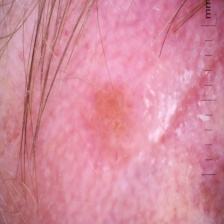

In [6]:
sample_image_path = df.loc[0, "image_path"]
sample_label = df.loc[0, "target"]

print(f"Sample image path: {sample_image_path}")
print(f"Label (0=benign, 1=melanoma): {sample_label}")

sample_image = Image.open(sample_image_path).convert("RGB")
print(f"Image dimensions: {sample_image.size}")
sample_image

## Train / Validation split (patient-level)

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 3
FOLDS_TO_RUN = [0, 1, 2]
RANDOM_STATE = 42

df = df.sort_values("image_name").reset_index(drop=True)

cv_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_splits = []
for fold, (train_idx, val_idx) in enumerate(
    cv_splitter.split(df, df["target"], groups=df["patient_id"])
):
    if fold in FOLDS_TO_RUN:
        fold_splits.append((fold, train_idx, val_idx))

print(f"Prepared folds: {FOLDS_TO_RUN}")

Prepared folds: [0, 1, 2]


## Dataset class

In [8]:
class MelanomaDataset(Dataset):
    """Custom PyTorch Dataset for binary melanoma classification."""

    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["target"], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

## DataLoaders

In [9]:
TRAIN_BATCH_SIZE = 64
VAL_BATCH_SIZE   = 256
NUM_WORKERS      = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def make_train_loader(train_df):
    train_dataset = MelanomaDataset(train_df, transform=train_transform)

    if imbalance_strategy == "weighted_sampler":
        labels = train_df["target"].values.astype(int)
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            persistent_workers=(NUM_WORKERS > 0)
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            persistent_workers=(NUM_WORKERS > 0)
        )

    return train_loader

def make_val_loader(val_df):
    val_dataset = MelanomaDataset(val_df, transform=val_transform)
    val_loader = DataLoader(
        val_dataset,
        batch_size=VAL_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(NUM_WORKERS > 0)
    )
    return val_loader

## Model — EfficientNet-B0


In [10]:
class MelanomaClassifier(nn.Module):
    """
    EfficientNet-B0 adapted for binary melanoma classification.
    The 1000-class head is replaced with a single linear neuron
    that outputs one logit for BCEWithLogitsLoss / Focal Loss.
    """

    def __init__(self, weights_path=None):
        super().__init__()

        if weights_path and Path(weights_path).exists():
            # --- Offline weights ---
            self.model = models.efficientnet_b0(weights=None)
            state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
            self.model.load_state_dict(state_dict)
            print(f"Loaded offline weights from {weights_path}")
        else:
            # --- Download from torchvision (requires internet) ---
            self.model = models.efficientnet_b0(weights='IMAGENET1K_V1')
            print("Downloaded ImageNet weights from torchvision")

        # Replace 1000-class head with binary head
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.model(x)

## Model setup

In [ ]:
# ── Adjust these paths if you have offline weights / a prior checkpoint ──
PRETRAINED_WEIGHTS_PATH = '/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth'
TRANSFER_MODEL_PATH     = "/AML_Project/inputs/efficientnet_b0_final_pre_train_full_ft_5fold_AUPRC_20epochs_balanced_bce_best_model.pth"
# ─────────────────────────────────────────────────────────────────────────

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def build_model():
    model = MelanomaClassifier(weights_path=PRETRAINED_WEIGHTS_PATH)

    if TRANSFER_MODEL_PATH and Path(TRANSFER_MODEL_PATH).exists():
        state_dict = torch.load(TRANSFER_MODEL_PATH, map_location="cpu", weights_only=True)
        model.load_state_dict(state_dict)
        print(f"Loaded baseline checkpoint from {TRANSFER_MODEL_PATH}")

    in_features = model.model.classifier[1].in_features
    model.model.classifier[1] = nn.Linear(in_features, 1)

    for param in model.parameters():
        param.requires_grad = True

    model = model.to(device)
    return model


Device: cuda:0


## Loss function & optimiser

In [12]:
# --- Loss function and optimiser ---
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

def build_training_components(model, train_df):
    if imbalance_strategy == "pos_weight":
        n_positive = train_df["target"].sum()
        n_negative = len(train_df) - n_positive
        pos_weight = torch.tensor([n_negative / n_positive], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
    else:
        criterion = nn.BCEWithLogitsLoss().to(device)

    trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())
    optimiser = optim.Adam(trainable_parameters, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    return criterion, optimiser


## Experiment setup — output paths & logging

In [13]:
imbalance_strategy = "pos_weight"   # "pos_weight" or "weighted_sampler"
EXPERIMENT_NAME = f"efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_{imbalance_strategy}"

WORKING_DIR = Path(OUTPUT_DIR)
WORKING_DIR.mkdir(parents=True, exist_ok=True)

def get_fold_paths(fold_idx):
    best_model_path      = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_best_model.pth"
    last_checkpoint_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_last_checkpoint.pth"
    log_path             = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_training_log.txt"
    return best_model_path, last_checkpoint_path, log_path

def log_message(message, log_path, printing=False):
    if printing:
        print(message)
    with open(log_path, "a") as f:
        f.write(message + "\n")

## Training & validation functions

In [14]:
def train_one_epoch(model, dataloader, criterion, optimiser, device, log_path=None):
    model.train()
    running_loss = correct = total = 0
    epoch_start = time.perf_counter()
    all_probs, all_labels = [], []

    for batch_idx, (images, labels) in enumerate(dataloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.unsqueeze(1).to(device, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimiser.step()

        probs      = torch.sigmoid(logits)
        pred       = (probs >= 0.5).float()

        bs         = images.size(0)
        running_loss += loss.item() * bs
        correct      += (pred == labels).sum().item()
        total        += bs

        all_probs.extend(probs.squeeze(1).detach().cpu().numpy())
        all_labels.extend(labels.squeeze(1).detach().cpu().numpy())

        if (batch_idx % 10 == 0 or batch_idx == len(dataloader)) and log_path is not None: 
            elapsed = time.perf_counter() - epoch_start
            log_message(
                f"Train [{batch_idx}/{len(dataloader)}] "
                f"Loss: {running_loss/total:.4f} "
                f"Acc: {correct/total:.4f} "
                f"Elapsed: {elapsed:.1f}s",
                log_path=log_path,
                printing=False
            )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    return {
        "loss":     running_loss / total,
        "accuracy": correct / total,
        "auroc":    roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),
    }


def validate_one_epoch(model, dataloader, criterion, device, use_tta=False, log_path=None):
    model.eval()
    running_loss = correct = total = 0
    epoch_start = time.perf_counter()
    all_probs, all_labels, all_preds = [], [], []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader, start=1):
            images = images.to(device, non_blocking=True)
            labels = labels.unsqueeze(1).to(device, non_blocking=True)

            if use_tta:
                logits_orig = model(images)
                loss_orig = criterion(logits_orig, labels)
                probs_orig  = torch.sigmoid(logits_orig)
                
                
                logits_hflip = model(torch.flip(images, dims=[3]))
                loss_hflip = criterion(logits_hflip, labels)
                probs_hflip  = torch.sigmoid(logits_hflip)

                loss = 0.5 * (loss_orig + loss_hflip)
                probs = 0.5 * (probs_orig + probs_hflip)

            else:
                logits = model(images)
                loss   = criterion(logits, labels)
                probs  = torch.sigmoid(logits)
            
        
            pred   = (probs >= 0.5).float()

            bs     = images.size(0)
            running_loss += loss.item() * bs
            correct      += (pred == labels).sum().item()
            total        += bs

            all_probs.extend(probs.squeeze(1).cpu().numpy())
            all_labels.extend(labels.squeeze(1).cpu().numpy())
            all_preds.extend(pred.squeeze(1).cpu().numpy())

            if batch_idx % 10 == 0 or batch_idx == len(dataloader):
                elapsed = time.perf_counter() - epoch_start
                if log_path is not None:
                    log_message(
                        f"Val [{batch_idx}/{len(dataloader)}] "
                        f"Loss: {running_loss/total:.4f} "
                        f"Acc: {correct/total:.4f} "
                        f"Elapsed: {elapsed:.1f}s",
                        log_path=log_path,
                        printing=False
                    )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "loss": running_loss / total,
        "accuracy": correct / total,
        "auroc": roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "specificity": specificity,
        "confusion_matrix": cm,
        "all_probs": all_probs,
        "all_labels": all_labels,
        "all_preds": all_preds,
    }

In [15]:
def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    results = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        results.append({
            "threshold": float(thr),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "specificity": specificity,
        })

    return pd.DataFrame(results)

## Training loop

In [16]:
num_epochs = 20
USE_TTA = False
checkpoint_metric = "auprc"   # "auroc" or "auprc"

all_fold_results = []

full_training_start = time.perf_counter()

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n===== Fold {fold_idx} =====")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    print(f"Train size: {len(train_df)} | positives: {int(train_df['target'].sum())}")
    print(f"Val size:   {len(val_df)} | positives: {int(val_df['target'].sum())}")

    train_loader = make_train_loader(train_df)
    val_loader = make_val_loader(val_df)

    model = build_model()
    criterion, optimiser = build_training_components(model, train_df)

    BEST_MODEL_PATH, LAST_CHECKPOINT_PATH, LOG_PATH = get_fold_paths(fold_idx)

    with open(LOG_PATH, "w") as f:
        f.write(f"Training log started at {datetime.now()}\n\n")

    best_val_metric = -1.0
    best_epoch = -1

    fold_history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_auroc": [],
        "val_auroc": [],
        "val_auprc": [],
        "val_f1": [],
    }

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()
        log_message(f"Starting epoch {epoch}/{num_epochs}...", log_path=LOG_PATH, printing=True)

        train_metrics = train_one_epoch(model, train_loader, criterion, optimiser, device, log_path=LOG_PATH)
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device, use_tta=USE_TTA, log_path=LOG_PATH)

        epoch_duration = time.perf_counter() - epoch_start

        fold_history["epoch"].append(epoch)
        fold_history["train_loss"].append(train_metrics["loss"])
        fold_history["val_loss"].append(val_metrics["loss"])
        fold_history["train_auroc"].append(train_metrics["auroc"])
        fold_history["val_auroc"].append(val_metrics["auroc"])
        fold_history["val_auprc"].append(val_metrics["auprc"])
        fold_history["val_f1"].append(val_metrics["f1"])

        log_message(
            f"Validation | Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['accuracy']:.4f} | "
            f"AUROC: {val_metrics['auroc']:.4f} | AUPRC: {val_metrics['auprc']:.4f} | "
            f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f} | "
            f"Specificity: {val_metrics['specificity']:.4f} | F1: {val_metrics['f1']:.4f}",
            log_path=LOG_PATH,
            printing=True
        )

        cm = val_metrics["confusion_matrix"]
        tn, fp, fn, tp = cm.ravel()
        log_message(
            f"Confusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}",
            log_path=LOG_PATH,
            printing=True
        )

        log_message(
            f"Epoch duration: {epoch_duration:.1f}s ({epoch_duration / 60:.2f} min)",
            log_path=LOG_PATH,
            printing=True
        )
        log_message("-" * 60, log_path=LOG_PATH, printing=True)

        current_metric = val_metrics[checkpoint_metric]
        if not math.isnan(current_metric) and current_metric > best_val_metric:
            best_val_metric = current_metric
            best_epoch = epoch
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            log_message(
                f"Best model saved ({checkpoint_metric.upper()} {best_val_metric:.4f})",
                log_path=LOG_PATH,
                printing=True
            )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimiser_state_dict": optimiser.state_dict(),
                "best_val_metric": best_val_metric,
                "checkpoint_metric": checkpoint_metric,
            },
            LAST_CHECKPOINT_PATH
        )

    history_df = pd.DataFrame(fold_history)
    history_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_history.csv"
    history_df.to_csv(history_path, index=False)

    print(f"Fold {fold_idx} best {checkpoint_metric.upper()}: {best_val_metric:.4f} (epoch {best_epoch})")
    print(f"Saved history to: {history_path}")

    all_fold_results.append(
        {
            "fold": fold_idx,
            "best_metric": best_val_metric,
            "best_epoch": best_epoch,
            "best_model_path": str(BEST_MODEL_PATH),
            "history_path": str(history_path),
            "checkpoint_metric": checkpoint_metric,
        }
    )

full_training_end = time.perf_counter()
total_training_time = full_training_end - full_training_start

summary_log_path = WORKING_DIR / f"{EXPERIMENT_NAME}_cv_summary.txt"
with open(summary_log_path, "w") as f:
    f.write("===== Cross-validation summary =====\n")
    for result in all_fold_results:
        f.write(
            f"Fold {result['fold']} | "
            f"Best {result['checkpoint_metric'].upper()}: {result['best_metric']:.4f} | "
            f"Best epoch: {result['best_epoch']}\n"
        )

    mean_best_metric = np.mean([x["best_metric"] for x in all_fold_results])
    f.write(f"\nMean best {checkpoint_metric.upper()} across folds: {mean_best_metric:.4f}\n")
    f.write(f"Total full training loop time: {total_training_time:.1f}s ({total_training_time / 60:.2f} min)\n")

print(f"Saved CV summary to: {summary_log_path}")


===== Fold 0 =====
Train size: 22080 | positives: 390
Val size:   11046 | positives: 194
Loaded offline weights from /user/HS401/ep01372/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline checkpoint from /user/HS401/ep01372/AML_Project/inputs/efficientnet_b0_final_pre_train_full_ft_5fold_AUPRC_20epochs_balanced_bce_best_model.pth
Starting epoch 1/20...
Validation | Loss: 1.1447 | Acc: 0.5996 | AUROC: 0.8279 | AUPRC: 0.0923 | Precision: 0.0384 | Recall: 0.9072 | Specificity: 0.5941 | F1: 0.0737
Confusion Matrix: TN=6447  FP=4405  FN=18  TP=176
Epoch duration: 58.8s (0.98 min)
------------------------------------------------------------
Best model saved (AUPRC 0.0923)
Starting epoch 2/20...
Validation | Loss: 1.0314 | Acc: 0.6384 | AUROC: 0.8611 | AUPRC: 0.1249 | Precision: 0.0437 | Recall: 0.9381 | Specificity: 0.6331 | F1: 0.0835
Confusion Matrix: TN=6870  FP=3982  FN=12  TP=182
Epoch duration: 58.6s (0.98 min)
---------------------------------------------------

# Plotting


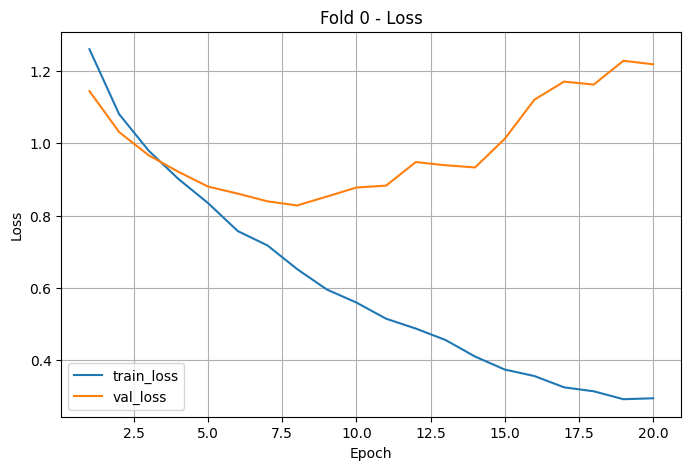

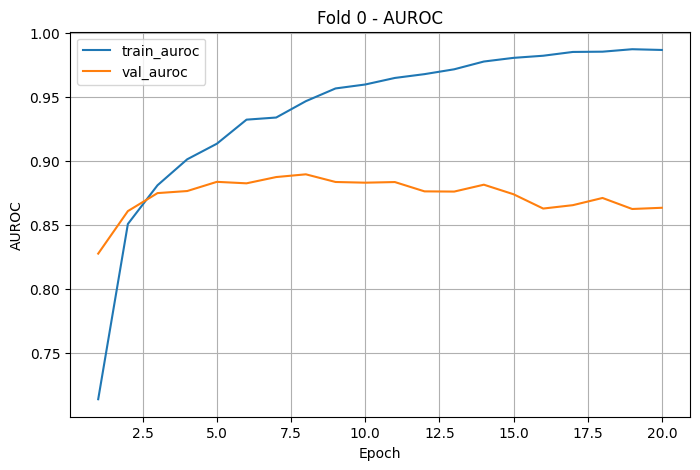

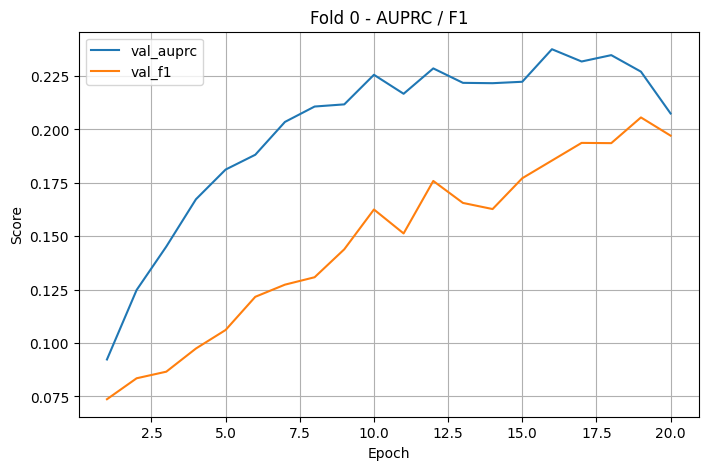

Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_0_loss.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_0_auroc.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_0_auprc_f1.png


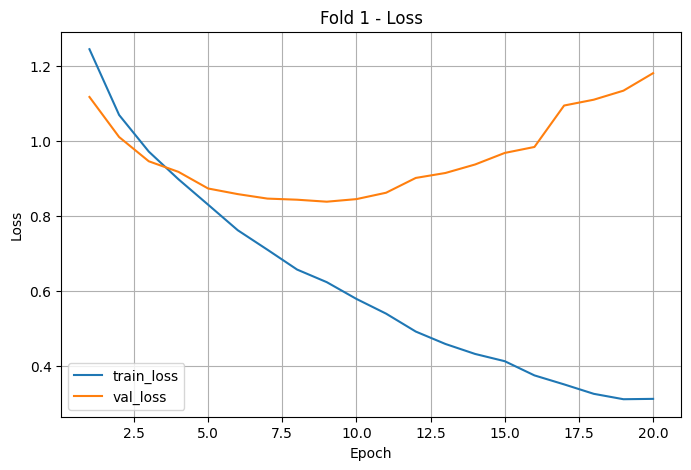

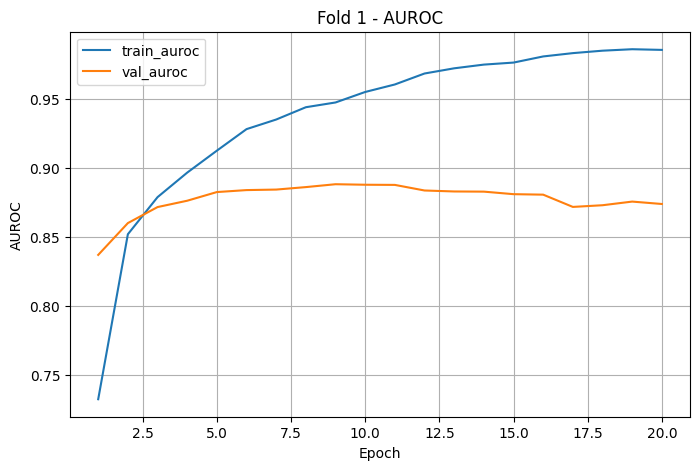

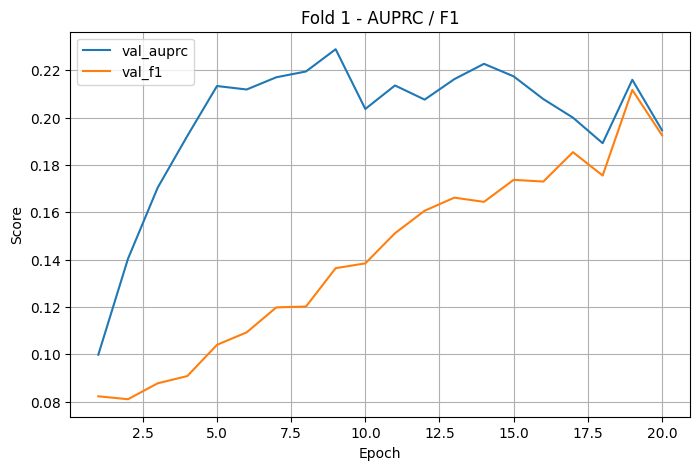

Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_1_loss.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_1_auroc.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_1_auprc_f1.png


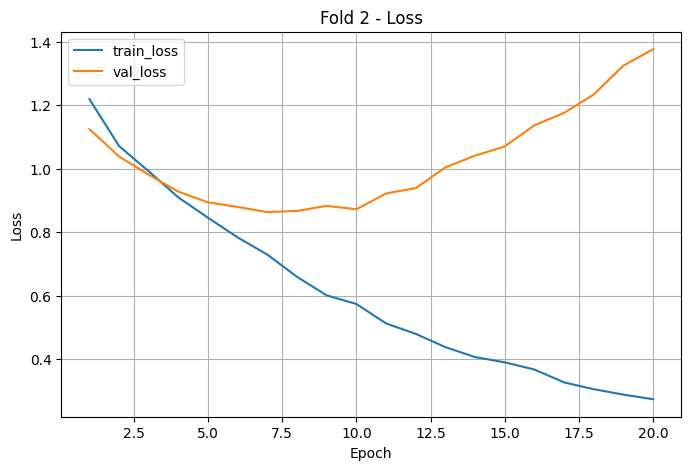

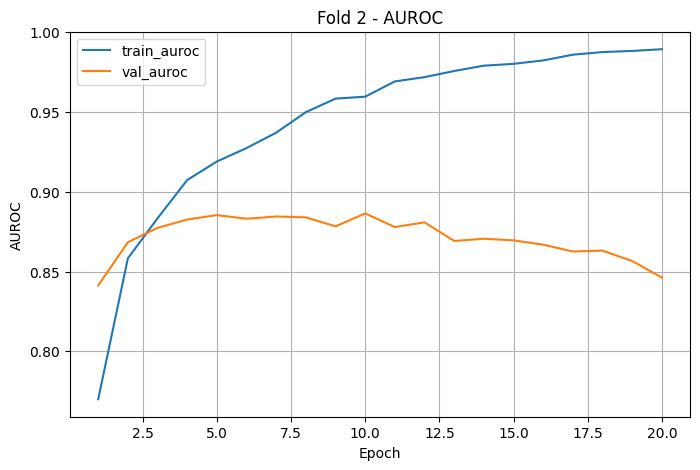

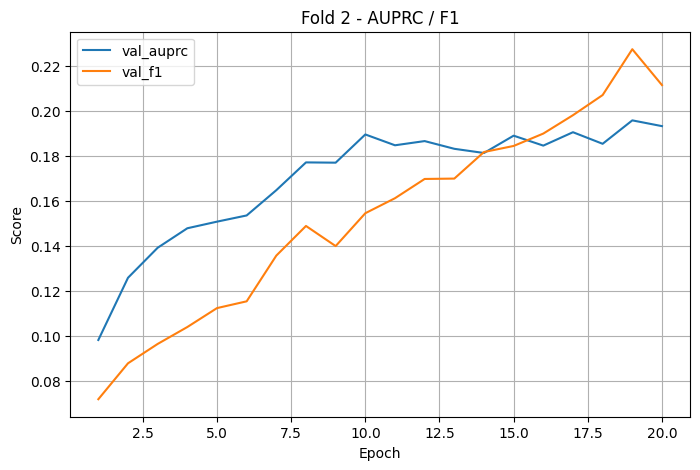

Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_2_loss.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_2_auroc.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_2_auprc_f1.png


In [21]:
for fold_idx in FOLDS_TO_RUN:
    history_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_history.csv"
    history_df = pd.read_csv(history_path)

    loss_plot_path  = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_loss.png"
    auroc_plot_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_auroc.png"
    score_plot_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_auprc_f1.png"

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_idx} - Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # AUROC
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_auroc"], label="train_auroc")
    plt.plot(history_df["epoch"], history_df["val_auroc"], label="val_auroc")
    plt.xlabel("Epoch")
    plt.ylabel("AUROC")
    plt.title(f"Fold {fold_idx} - AUROC")
    plt.legend()
    plt.grid(True)
    plt.savefig(auroc_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # AUPRC / F1
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_auprc"], label="val_auprc")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"Fold {fold_idx} - AUPRC / F1")
    plt.legend()
    plt.grid(True)
    plt.savefig(score_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {loss_plot_path}")
    print(f"Saved: {auroc_plot_path}")
    print(f"Saved: {score_plot_path}")

# OOF and TTA

In [22]:
USE_TTA_EVAL = True

oof_probs = []
oof_labels = []
oof_records = []
fold_oof_results = []

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n===== OOF evaluation fold {fold_idx} =====")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    val_loader = make_val_loader(val_df)

    model = build_model()
    BEST_MODEL_PATH, _, _ = get_fold_paths(fold_idx)

    state_dict = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    criterion, _ = build_training_components(model, train_df)

    val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device,
        use_tta=USE_TTA_EVAL
    )

    fold_oof_results.append({
        "fold": fold_idx,
        "auroc": val_metrics["auroc"],
        "auprc": val_metrics["auprc"],
        "f1": val_metrics["f1"],
    })

    fold_probs = val_metrics["all_probs"]
    fold_labels = val_metrics["all_labels"]

    fold_pred_df = val_df[["image_name", "target"]].copy()
    fold_pred_df["fold"] = fold_idx
    fold_pred_df["prob"] = fold_probs
    fold_pred_df["pred_05"] = (fold_pred_df["prob"] >= 0.5).astype(int)

    fold_csv_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_val_predictions.csv"
    fold_pred_df.to_csv(fold_csv_path, index=False)
    print(f"Saved: {fold_csv_path}")

    oof_records.append(fold_pred_df)
    oof_probs.extend(fold_probs)
    oof_labels.extend(fold_labels)

oof_probs = np.array(oof_probs)
oof_labels = np.array(oof_labels)

oof_pred_df = pd.concat(oof_records, axis=0, ignore_index=True)
oof_pred_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_predictions.csv"
oof_pred_df.to_csv(oof_pred_path, index=False)

oof_auroc = roc_auc_score(oof_labels, oof_probs)
oof_auprc = average_precision_score(oof_labels, oof_probs)


# Define the path for the OOF summary text file
oof_summary_txt_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_summary.txt"

# Open the file in write mode ("w")
with open(oof_summary_txt_path, "w") as f:
    
    # Log per-fold metrics
    title_fold = "===== Per-fold OOF metrics ====="
    print(f"\n{title_fold}")
    f.write(f"{title_fold}\n")
    
    for result in fold_oof_results:
        line = (
            f"Fold {result['fold']} | "
            f"AUROC: {result['auroc']:.4f} | "
            f"AUPRC: {result['auprc']:.4f} | "
            f"F1@0.5: {result['f1']:.4f}"
        )
        print(line)
        f.write(f"{line}\n")
        
    # Log global metrics
    title_global = "===== Global OOF metrics ====="
    print(f"\n{title_global}")
    f.write(f"\n{title_global}\n")
    
    line_auroc = f"OOF AUROC: {oof_auroc:.4f}"
    line_auprc = f"OOF AUPRC: {oof_auprc:.4f}"
    
    print(line_auroc)
    print(line_auprc)
    f.write(f"{line_auroc}\n")
    f.write(f"{line_auprc}\n")

# Console confirmation
print(f"\nSaved OOF metrics summary to: {oof_summary_txt_path}")

oof_threshold_df = threshold_sweep(oof_labels, oof_probs)
oof_threshold_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_threshold_sweep.csv"
oof_threshold_df.to_csv(oof_threshold_path, index=False)

display(oof_threshold_df)

best_idx = oof_threshold_df["f1"].idxmax()
best_row = oof_threshold_df.loc[best_idx]
best_thr = float(best_row["threshold"])

print("\nBest OOF threshold by F1:")
print(best_row)

# APPEND BEST THRESHOLD TO THE SUMMARY TXT

with open(oof_summary_txt_path, "a") as f:  
    f.write("\n===== Best OOF Threshold by F1 =====\n")
    f.write(f"Threshold: {best_thr:.4f}\n")
    f.write(f"F1 Score:  {best_row['f1']:.4f}\n")
    f.write(f"Precision: {best_row['precision']:.4f}\n")
    f.write(f"Recall:    {best_row['recall']:.4f}\n")

print(f"\nAppended best threshold metrics to: {oof_summary_txt_path}")



===== OOF evaluation fold 0 =====
Loaded offline weights from /user/HS401/ep01372/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline checkpoint from /user/HS401/ep01372/AML_Project/inputs/efficientnet_b0_final_pre_train_full_ft_5fold_AUPRC_20epochs_balanced_bce_best_model.pth
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_0_val_predictions.csv

===== OOF evaluation fold 1 =====
Loaded offline weights from /user/HS401/ep01372/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline checkpoint from /user/HS401/ep01372/AML_Project/inputs/efficientnet_b0_final_pre_train_full_ft_5fold_AUPRC_20epochs_balanced_bce_best_model.pth
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_fold_1_val_predictions.csv

===== OOF evaluation fold 2 =====
Loaded offline weights from /user/HS401/ep01372/AML_Project/inputs/ef

,threshold,precision,recall,f1,specificity
0,0.05,0.028429,0.934932,0.055179,0.426587
1,0.10,0.039054,0.876712,0.074777,0.612870
2,0.15,0.048250,0.847603,0.091303,0.699957
3,0.20,0.056013,0.815068,0.104823,0.753488
4,0.25,0.062286,0.779110,0.115350,0.789503
5,0.30,0.067061,0.738014,0.122950,0.815746
6,0.35,0.074298,0.715753,0.134622,0.839961
7,0.40,0.082462,0.702055,0.147588,0.859812
8,0.45,0.091118,0.679795,0.160696,0.878311
9,0.50,0.099712,0.652397,0.172985,0.894290



Best OOF threshold by F1:
threshold      0.900000
precision      0.252288
recall         0.330479
f1             0.286138
specificity    0.982423
Name: 17, dtype: float64

Appended best threshold metrics to: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_summary.txt


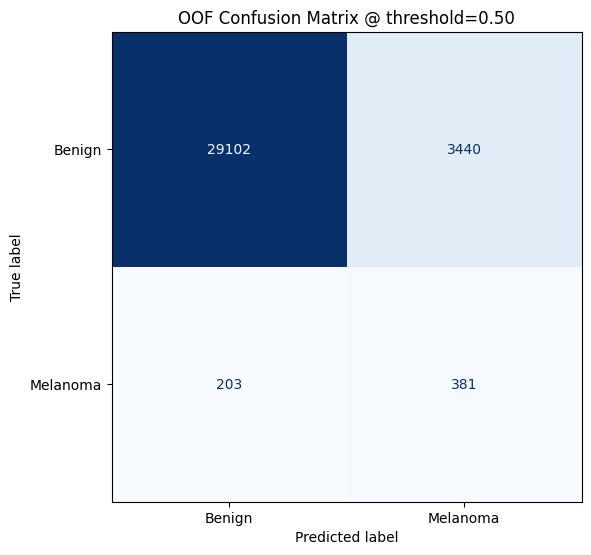

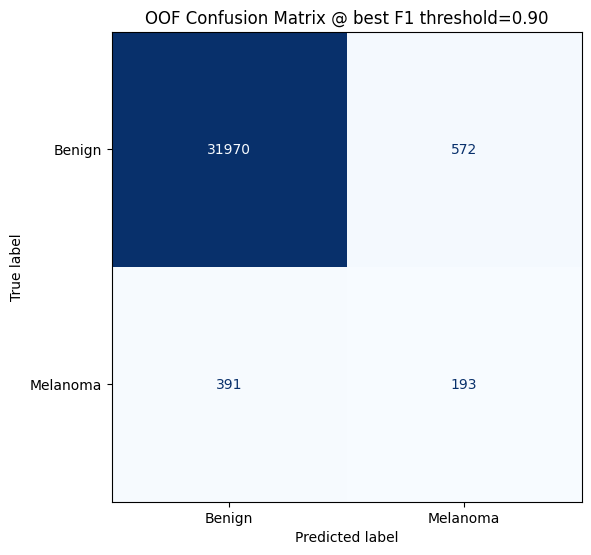


Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_predictions.csv
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_threshold_sweep.csv
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_confusion_matrix_t050.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_confusion_matrix_best_f1.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_metrics.json


In [23]:
def save_confusion_matrix_figure(y_true, y_prob, threshold, save_path, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    class_labels = ['Benign', 'Melanoma']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
    }
    return metrics

cm_05_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_confusion_matrix_t050.png"
cm_best_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_confusion_matrix_best_f1.png"

cm_metrics_05 = save_confusion_matrix_figure(
    oof_labels,
    oof_probs,
    threshold=0.5,
    save_path=cm_05_path,
    title="OOF Confusion Matrix @ threshold=0.50"
)

cm_metrics_best = save_confusion_matrix_figure(
    oof_labels,
    oof_probs,
    threshold=best_thr,
    save_path=cm_best_path,
    title=f"OOF Confusion Matrix @ best F1 threshold={best_thr:.2f}"
)

oof_metrics = {
    "oof_auroc": float(oof_auroc),
    "oof_auprc": float(oof_auprc),
    "best_f1_threshold": best_thr,
    "cm_at_050": cm_metrics_05,
    "cm_at_best_f1": cm_metrics_best,
}

metrics_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_metrics.json"
with open(metrics_path, "w") as f:
    import json
    json.dump(oof_metrics, f, indent=2)

print(f"\nSaved: {oof_pred_path}")
print(f"Saved: {oof_threshold_path}")
print(f"Saved: {cm_05_path}")
print(f"Saved: {cm_best_path}")
print(f"Saved: {metrics_path}")

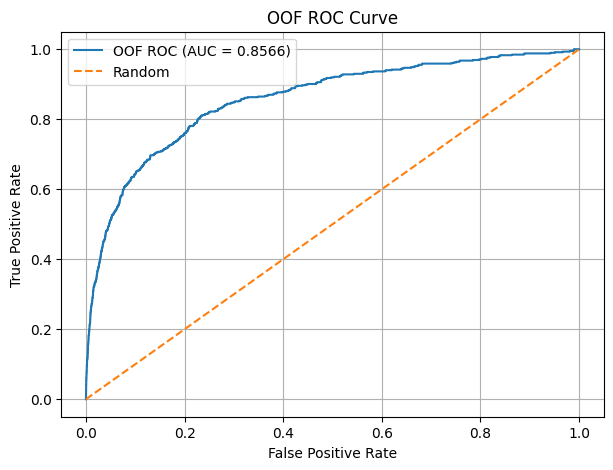

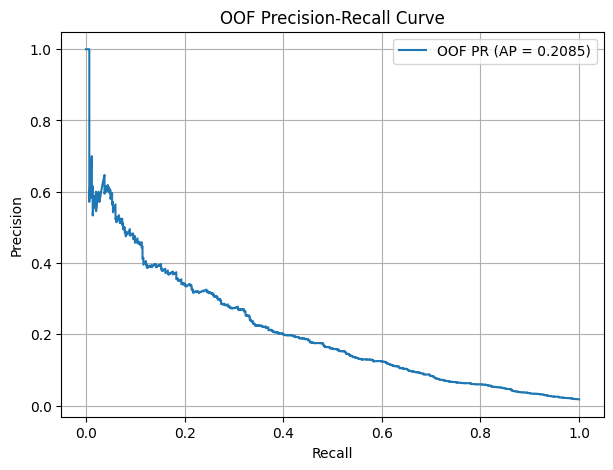

Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_roc.png
Saved: /user/HS401/ep01372/AML_Project/outputs/efficientnet_b0_transfer_full_ft_BCE_3fold_TTA_AUPRC_20epochs_pos_weight_oof_pr.png


In [24]:
roc_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_roc.png"
pr_path  = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_pr.png"


fpr, tpr, _ = roc_curve(oof_labels, oof_probs)
precision_pr, recall_pr, _ = precision_recall_curve(oof_labels, oof_probs)

roc_auc = oof_auroc
ap = oof_auprc

# ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"OOF ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(roc_path, bbox_inches="tight")
plt.show()

# PR
plt.figure(figsize=(7, 5))
plt.plot(recall_pr, precision_pr, label=f"OOF PR (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("OOF Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig(pr_path, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)
print("Saved:", pr_path)